![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge ID.

In our exercise, we are tasked with identifying all SNOTEL sites upstream of Hetch Hetchy Reservoir on the Tuolumne River. The user can search for "USGS streamflow Tuolumne River" and serveral locations will pop up. Site [11274790](https://waterdata.usgs.gov/monitoring-location/11274790/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false) is the site of interest for this assessment 


# River Network

In [15]:
from __future__ import annotations

from pathlib import Path
import dataretrieval.nwis as nwis
from datetime import datetime
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pynhd as nhd
from pynhd import NLDI, NHDPlusHR, WaterData
import py3dep
import pygeohydro as gh

from pathlib import Path
import networkx as nx
import xarray as xr
import xrspatial
import os

[PyNHD](https://github.com/cheginit/pynhd) provides access to the Hydro Network-Linked Data Index ([NLDI](https://labs.waterdata.usgs.gov/about-nldi/index.html)) and the [WaterData](https://labs.waterdata.usgs.gov/geoserver/web/wicket/bookmarkable/org.geoserver.web.demo.MapPreviewPage?1) web services for navigating and subsetting [NHDPlus](https://nhdplus.com/NHDPlus) V2 database. Additionally, you can download NHDPlus High Resolution data as well.

First, let's get the watershed geometry of the contributing basin of a USGS station using `NLDI`:

In [ ]:
nldi = NLDI()
station_id = "11274790" # NWIS id for Tuolumne river at the mouth of Hetch Hetchy Reservoir
basinname = 'TuolumneRiverBasin'
#Getting basin geometry
basin = nldi.get_basins(station_id)
geometry = basin.geometry.iloc[0]


: 

: 

The `navigate_byid` class method can be used to navigate NHDPlus in both upstream and downstream of any point in the database. The available feature sources are ``comid``, ``huc12pp``, ``nwissite``, ``wade``, ``wqp``. Let's get ComIDs and flowlines of the tributaries and the main river channel in the upstream of the station.

In [ ]:
#Get the flowlines for the mainstem of the station
flw_main = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamMain",
    source="flowlines",
    distance=1000,
)

#Get the flowlines for the Tributaries of the station
flw_trib = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamTributaries",
    source="flowlines",
    distance=1000,
)

: 

: 

We can get other USGS stations upstream (or downstream) of the station and even set a distance limit (in km):

In [ ]:
#Get the stations for the upstream of the station within 1000 km
st_all = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamTributaries",
    source="nwissite",
    distance=1000,
)

#make a list of station ids from the provider_id column of st_all
station_ids = st_all['identifier'].str.replace('USGS-', '').tolist()

# Retrieve site info (which includes the period of record)
# 'seriesCatalogOutput=True' tells NWIS to return the list of parameters and their dates
inventory_df, metadata = nwis.get_info(sites=station_ids, seriesCatalogOutput=True)

#Filter for a specific parameter (e.g., 00060 is Discharge)
# # Note: get_info returns a row for every parameter/statistic combination at each site
discharge_info = inventory_df[inventory_df['parm_cd'] == '00060']

# # 4. View the start and end dates
df = discharge_info[['site_no', 'station_nm', 'begin_date', 'end_date']]
#drop duplicate rows based on site_no, keeping the first occurrence (which has the full period of record)
df = df.drop_duplicates(subset='site_no', keep='first').reset_index(drop=True)

#select rows based on the end date being after 2025-01-01
st_active = df[df['end_date'] > '2025-01-01']

#get a list of active station ids
active_station_ids = st_active['site_no'].tolist()
#add USGS- prefix to the station ids
active_station_ids = ['USGS-' + id for id in active_station_ids]

#select rows from st_all that have an identifier in the active_station_ids list
st_active = st_all[st_all['identifier'].isin(active_station_ids)]

/opt/homebrew/Caskroom/miniforge/base/envs/hyriver/lib/python3.10/site-packages/dataretrieval/nwis.py:692: UserWarning: WARNING: Starting in March 2024, the NWIS qw data endpoint is retiring and no longer receives updates. For more information, refer to https://waterdata.usgs.gov.nwis/qwdata and https://doi-usgs.github.io/dataRetrieval/articles/Status.html or email CompTools@usgs.gov.
  warnings.warn(


: 

: 

Now, let's get the [HUC12 pour points](https://www.sciencebase.gov/catalog/item/5762b664e4b07657d19a71ea):

In [16]:
#Get the flow points where HUC12 boundaries intersect with the flowlines for the tributaries of the station
pp = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamTributaries",
    source="huc12pp",
    distance=1000,
)

Let's plot the vector data:

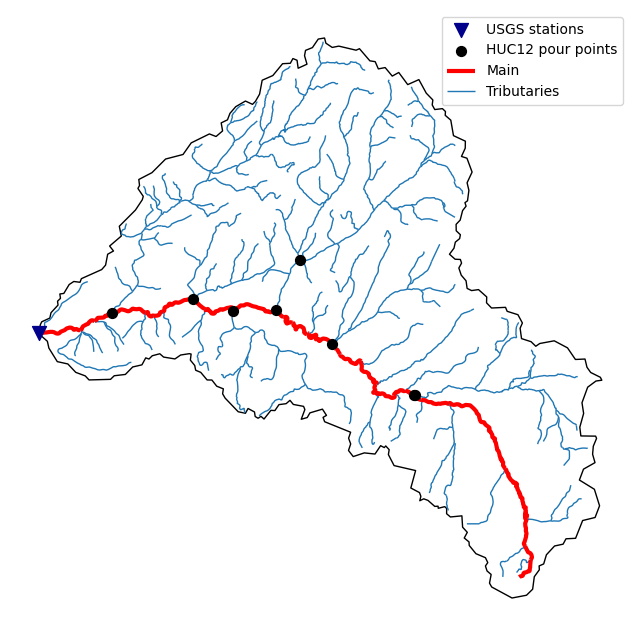

: 

: 

In [ ]:
#Plot the basin, flowlines, and stations
ax = basin.plot(facecolor="none", edgecolor="k", figsize=(8, 8))
st_active.plot(
    ax=ax,
    label="USGS stations",
    marker="v",
    markersize=100,
    zorder=5,
    color="darkblue",
)
pp.plot(ax=ax, label="HUC12 pour points", marker="o", markersize=50, color="k", zorder=3)
flw_main.plot(ax=ax, lw=3, color="r", zorder=2, label="Main")
flw_trib.plot(ax=ax, lw=1, zorder=1, label="Tributaries")
ax.legend(loc="best")
ax.set_aspect("auto")
ax.set_axis_off()
ax.figure.set_dpi(100)
ax.figure.savefig("Figures/nhdplus_navigation.png", bbox_inches="tight", facecolor="w")

Next, we get the slope data for each river segment from NHDPlus VAA database:

In [ ]:
#Get the slope attribute for the flowlines of the tributaries of the station
vaa = nhd.nhdplus_vaa("input_data/nhdplus_vaa.parquet")
flw_trib["comid"] = pd.to_numeric(flw_trib.nhdplus_comid)
slope = gpd.GeoDataFrame(
    pd.merge(flw_trib, vaa[["comid", "slope"]], left_on="comid", right_on="comid"),
    crs=flw_trib.crs,
)
slope[slope.slope < 0] = np.nan

: 

: 

In [ ]:
slope.head()

,geometry,nhdplus_comid,comid,slope
0,"LINESTRING (-119.65581 37.91679, -119.6567 37....",17081597,17081597.0,0.066691
1,"LINESTRING (-119.62574 37.91856, -119.626 37.9...",17081601,17081601.0,0.030729
2,"LINESTRING (-119.61982 37.95082, -119.62118 37...",17081593,17081593.0,0.270988
3,"LINESTRING (-119.61431 37.92446, -119.61543 37...",17081583,17081583.0,0.012108
4,"LINESTRING (-119.62473 37.91721, -119.62574 37...",17081595,17081595.0,0.309143


: 

: 

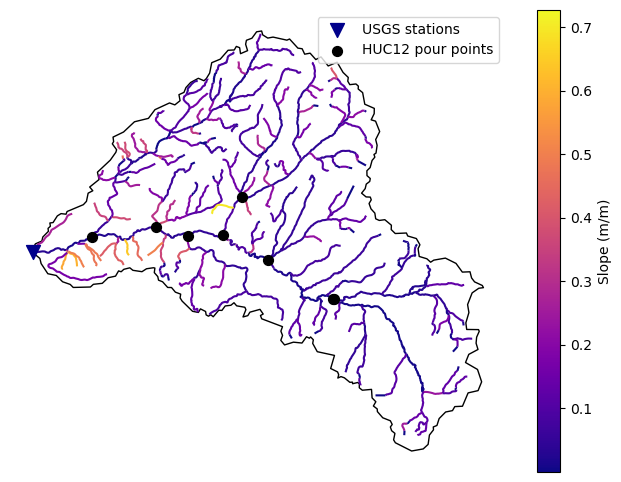

In [17]:
#Plot the slope attribute for the flowlines of the tributaries of the station
ax = basin.plot(facecolor="none", edgecolor="k", figsize=(8, 6))
slope.plot(
    ax=ax,  
    column="slope",
    cmap="plasma",
    legend=True,
    legend_kwds={"label": "Slope (m/m)"},
)

st_active.plot(
    ax=ax,
    label="USGS stations",
    marker="v",
    markersize=100,
    zorder=5,
    color="darkblue",
)
pp.plot(ax=ax, label="HUC12 pour points", marker="o", markersize=50, color="k", zorder=3)

ax.legend(loc="best")
ax.set_aspect("auto")
ax.set_axis_off()
ax.figure.set_dpi(100)

ax.set_axis_off()

Let's get Mean Annual Groundwater Recharge, ``CAT_RECHG``, using ``getcharacteristic`` class method and carry out the flow accumulation. Catchment recharge is from the [USGS StreamCat Dataset](https://water.usgs.gov/catalog/datasets/f5bc87be-8f39-44a9-8d25-e2108db06522/) orgiginally developed by [Hill et al., 2016](https://doi.org/10.1111/1752-1688.12372). The underlying data used to create this metric comes from a USGS 1-km resolution raster map of mean annual groundwater recharge for the conterminous United States.

Since NHDPlus HR is still at the pre-release stage, let's use the MR flowlines to demonstrate the vector-based accumulation.

Based on a topological sorted river network ``pynhd.vector_accumulation`` computes flow accumulation in the network. It returns a dataframe which is sorted from upstream to downstream that shows the accumulated flow in each node.

PyNHD has a utility called ``prepare_nhdplus`` that identifies such relationship among other things such as fixing some common issues with NHDPlus flowlines. But first we need to get all the NHDPlus attributes for each ComID since `NLDI` only provides the flowlines' geometries and ComIDs which is useful for navigating the vector river network data. For getting the NHDPlus database we use ``WaterData``. The WaterData web service layers are  ``nhdflowline_network``, ``nhdarea``, ``nhdwaterbody``, ``catchmentsp``, ``gagesii``, ``huc08``, ``huc12``, ``huc12agg``, and ``huc12all``. Let's use the ``nhdflowline_network`` layer to get required info.

In [18]:
comids = [int(c) for c in flw_trib.nhdplus_comid.to_list()]
nhdp_mr = WaterData("nhdflowline_network")
nhdp_trib = nhdp_mr.byid("comid", comids)
flw = nhd.prepare_nhdplus(nhdp_trib, 0, 0, purge_non_dendritic=False)

Since these are catchment-scale characteristic, let's get the catchments then add the accumulated characteristic as a new column and plot the results.

In [19]:
char = "CAT_RECHG" # This is the NHDPlus attribute for catchment recharge in mm/year
area = "areasqkm" # This is the NHDPlus attribute for catchment area in square kilometers

local = nldi.get_characteristics(char, comids) # Get the catchment recharge values for the comids
flw = flw.merge(local[char], left_on="comid", right_index=True) # Merge the recharge values into the flowline dataframe

# Define an accumulation function for runoff that takes into account the recharge and area of each catchment
def runoff_acc(qin, q, a): #qin is the accumulated runoff from upstream, q is the recharge for the current catchment, and a is the area of the current catchment
    return qin + q * a

# Create a new dataframe with the necessary columns for accumulation
flw_r = flw[["comid", "tocomid", char, area]]
runoff = nhd.vector_accumulation(flw_r, runoff_acc, char, [char, area]) # Accumulate runoff using the recharge and area values

# Define an accumulation function for area that simply sums the areas of upstream catchments
def area_acc(ain, a): #ain is the accumulated area from upstream, and a is the area of the current catchment
    return ain + a

# Create a new dataframe with the necessary columns for accumulation
flw_a = flw[["comid", "tocomid", area]]
areasqkm = nhd.vector_accumulation(flw_a, area_acc, area, [area]) # Accumulate area by summing the areas of upstream catchments


runoff /= areasqkm # Calculate runoff in mm/year by dividing the accumulated recharge by the accumulated area

Now, let's use [WaterData](https://labs.waterdata.usgs.gov/geoserver/web/) service to get the headwater catchments for this basin:

In [20]:
wd_cat = WaterData("catchmentsp") # Get the catchments for the flowlines of the tributaries of the station
cat = wd_cat.bygeom(basin.geometry.iloc[0], predicate="overlaps")# Get the catchments that overlap with the basin geometry

catchments = wd_cat.byid("featureid", comids) # Get the catchments for the comids of the flowlines of the tributaries of the station

c_local = catchments.merge(local, left_on="featureid", right_index=True) # Merge the local recharge values into the catchment dataframe
c_acc = catchments.merge(runoff, left_on="featureid", right_index=True) # Merge the accumulated runoff values into the catchment dataframe

/var/folders/gt/m7_lxk5j1mn90fqjrx8y57300000gn/T/ipykernel_60991/3686794627.py:4: UserWarning: 1 of 365 requests failed.. IDs of the failed requests are ['17077353']
  catchments = wd_cat.byid("featureid", comids) # Get the catchments for the comids of the flowlines of the tributaries of the station


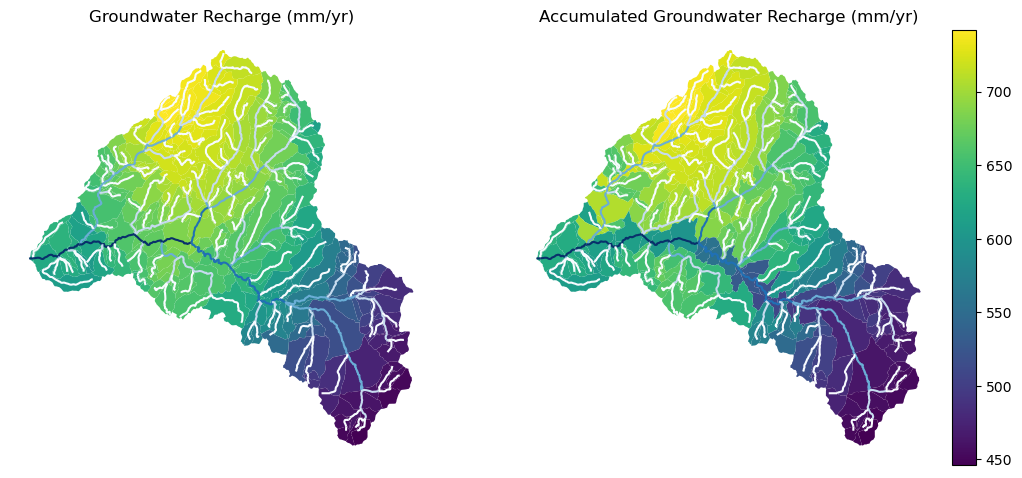

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), facecolor="w")

cmap = "viridis"
norm = plt.Normalize(vmin=c_local.CAT_RECHG.min(), vmax=c_acc.acc_CAT_RECHG.max()) # Use the same normalization for both plots to ensure the color scales are comparable

c_local.plot(ax=ax1, column=char, cmap=cmap, norm=norm)
flw.plot(ax=ax1, column="streamorde", cmap="Blues", scheme="fisher_jenks")
ax1.set_title("Groundwater Recharge (mm/yr)")
ax1.set_axis_off()

c_acc.plot(ax=ax2, column=f"acc_{char}", cmap=cmap, norm=norm)
flw.plot(ax=ax2, column="streamorde", cmap="Blues", scheme="fisher_jenks")
ax2.set_title("Accumulated Groundwater Recharge (mm/yr)")
ax2.set_axis_off()

cax = fig.add_axes(
    [
        ax2.get_position().x1 + 0.01,
        ax2.get_position().y0,
        0.02,
        ax2.get_position().height,
    ]
)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, cax=cax)
fig.savefig(Path("Figures", "flow_accumulation.png"), bbox_inches="tight", facecolor="w")

## Get Basin Attributes

Use the [Py3DEP](https://github.com/hyriver/py3dep) package to get geospatial information about our catchment.

In [22]:
topo = py3dep.get_map(["DEM", "Slope Degrees"], geometry, 90, geo_crs=4326, crs=5070) # Get the DEM and slope for the basin geometry at 90m resolution, reproject to 5070, and convert slope from degrees to m/m
dem = py3dep.get_dem(geometry, 30) # Get the DEM for the basin geometry at 30m resolution
dem = dem.rio.reproject(5070) # Reproject the DEM to match the CRS of the slope and the flowlines
slope = py3dep.deg2mpm(xrspatial.slope(dem)) # Calculate slope in m/m from the DEM using xrspatial, which handles the spatial resolution and units correctly
topo = xr.merge([dem, slope]) # Merge the DEM and slope into a single xarray dataset


if not os.path.exists('files/DEM'):
    os.makedirs('files/DEM')
dem.rio.to_raster(Path("files/DEM", f"dem_{station_id}.tif"))

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 4))
dem.plot(ax=axs[0])
slope.plot(ax=axs[1])
for ax in axs:
    ax.set_title("")
    ax.set_axis_off()
fig.savefig("Figures/dem_slope.png", bbox_inches="tight", facecolor="w")

: 

: 

: 

In [ ]:
# build a dataframe to get record basin information
#get a range of elevation within the basin
ave_basin_elevation = topo.elevation.mean().values
min_basin_elevation = topo.elevation.min().values
max_basin_elevation = topo.elevation.max().values

#get the average slope of the basin
ave_basin_slope = topo.slope.mean().values

#get the basin area
gs = gpd.GeoSeries([geometry], crs="EPSG:4326")

# Project to a metric system (EPSG:3857 is Web Mercator / meters)
gs_meters = gs.to_crs(epsg=3857)

# Calculate area (returns square meters)
area_m2 = gs_meters.area.iloc[0]
area_km2 = area_m2 / 1_000_000

#Put the informatininto  a dataframe
basin_info = pd.DataFrame({
    "Basin_Name": [basinname],
    "station_id": [station_id],
    "Average_Elevation_m": [ave_basin_elevation],
    "Minimum_Elevation_m": [min_basin_elevation],
    "Maximum_Elevation_m": [max_basin_elevation],
    "Average_Slope": [ave_basin_slope],
    "Area_km2": [area_km2],
})

gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[geometry])

# Use this gdf in your nlcd_bygeom call nlcd is the National Land Cover Database, and nlcd_bygeom is a function in pygeohydro that retrieves the land cover types within a given geometry
# nlcd_data = gh.nlcd_bygeom(gdf)

# station_ids = [station_id]
# #geometry = NLDI().get_basins(station_ids)
# basin.index = station_ids

: 

: 

: 

## Get basin land cover and land user inforation
We can use [PyGeoHydro](https://github.com/hyriver/pygeohydro) to access data from the [National Land Cover Database](https://www.usgs.gov/centers/eros/science/national-land-cover-database) and get basin statistics.

In [ ]:
# cover and impervious descriptor data at a 100 m resolution for all three stations
desc = gh.nlcd_bygeom(basin.geometry, 100, years={"descriptor": 2019}, ssl=False)
#land cover data at a 100 m resolution for all three stations for 2016 and 2019
lulc = gh.nlcd_bygeom(basin.geometry, 100, years={"cover": [2016, 2019]}, ssl=False)


: 

: 

In [ ]:
stats = gh.cover_statistics(lulc[f"USGS-{station_id}"].cover_2019) # Get the land cover statistics for the 2019 land cover data for the station's basin geometry
roughness = gh.overland_roughness(lulc[f"USGS-{station_id}"].cover_2019) # Get the overland flow roughness for the 2019 land cover data for the station's basin geometry

: 

: 

In [ ]:
cmap, norm, levels = gh.plot.cover_legends() # Get the colormap, normalization, and levels for plotting land cover data using pygeohydro's built-in legends
cover = lulc[f"USGS-{station_id}"].cover_2019 # Get the 2019 land cover data for the station's basin geometry
unique_lulc = np.unique(cover.values) # Get the unique land cover codes present in the cover data for the station's basin geometry

nlcd_legend = {
    11: "Open Water",
    12: "Perennial Ice/Snow",
    21: "Developed, Open Space",
    22: "Developed, Low Intensity",
    23: "Developed, Medium Intensity",
    24: "Developed, High Intensity",
    31: "Barren Land (Rock/Sand/Clay)",
    41: "Deciduous Forest",
    42: "Evergreen Forest",
    43: "Mixed Forest",
    52: "Shrub/Scrub",
    71: "Grassland/Herbaceous",
    90: "Woody Wetlands",
    95: "Emergent Herbaceous Wetlands",
    127: "No Data / Masked"  # Often used as a fill or background value
}

# To translate your list of unique values:
unique_names = [nlcd_legend.get(code, "Unknown") for code in unique_lulc]


unique_names


: 

: 

In [ ]:
#Create a vectorized version of your dictionary mapping
def map_names(val):
    return nlcd_legend.get(val, "Unknown")

# Create a vectorized function that can be applied to the entire array of land cover codes to get the corresponding names
v_map_names = np.vectorize(map_names) 

# Create a new DataArray with the string names
cover_names = xr.apply_ufunc(v_map_names, cover)

# Get unique values and their pixel counts
vals, counts = np.unique(cover.values, return_counts=True)

# Build a summary DataFrame
summary = pd.DataFrame({
    "code": vals,
    "count": counts,
    "name": [nlcd_legend.get(v, "Unknown") for v in vals]
})

# Calculate percentage (ignoring 127/No Data in the total pixel count)
total_pixels = summary[summary['code'] != 127]['count'].sum()
summary['percent'] = (summary['count'] / total_pixels) * 100
summary = summary[summary['code'] != 127]

#print(summary.sort_values("percent", ascending=False))

# copy the summary dataframe to a new variable to transpose
lulc = summary.copy()
#remove the following columns from the dataframe: count, code
lulc = lulc.drop(columns=["count", "code"])
#set the name column as the index of the dataframe
lulc.rename(columns={"name": "Basin_Name", 'percent': basin_info['Basin_Name'].values[0]}, inplace=True)
lulc.set_index("Basin_Name", inplace=True)
#transpose the dataframe
lulc = lulc.T
lulc.columns = lulc.columns.str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("/", "_")

# #combine the basin info dataframe with the lulc dataframe
basin_info.set_index('Basin_Name', inplace=True)
basin_info = pd.concat([basin_info, lulc], axis=1)

OutputFolder = 'files/basin_info'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
basin_info.to_csv(f'{OutputFolder}/basin_info_{station_id}.csv')

basin_info


: 

: 

## Plot our data!
Now that we have dont all of the hard work, lets see what our watershed is all about

In [ ]:
# Mask 127 to make it transparent
cover_masked = cover.where(cover != 127)

# Capture the plot object as 'im'
fig, ax = plt.subplots(figsize=(10, 8))
im = cover_masked.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)

# Filter your labels to exclude 127
plot_values = [v for v in unique_lulc if v != 127]
plot_names = [nlcd_legend.get(v, "Unknown") for v in plot_values]

# Now 'im' is defined and can be used for the colorbar
cbar = fig.colorbar(im, ax=ax, ticks=plot_values, fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(plot_names)
ax.set_title(f"Land Cover: {station_id} (2019)")


plt.show()



: 

: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
cover.where(cover < 127).plot(ax=ax1, cmap=cmap, levels=levels, cbar_kwargs={"ticks": levels[:-1]})
ax1.set_title("Land Use/Land Cover 2019")
ax1.set_axis_off()

roughness.plot(ax=ax2)
ax2.set_title("Overland Roughness")
ax2.set_axis_off()
fig.savefig(Path("Figures", "lulc.png"), bbox_inches="tight", facecolor="w")

: 

: 

## Now that we have static catchment information, lets combine it all into one dataframe!

We can put our Snotel, streamflow, met data, and catchment attriutes into one dataframe in [HydroDF](HydroDF_Analysis.ipynb)

: 

: 

: 

: 

# Extras

In [ ]:
wd_cat = WaterData("catchmentsp")
cat = wd_cat.bygeom(basin.geometry.iloc[0], predicate="overlaps")

: 

: 

In [ ]:
ax = cat.plot(figsize=(8, 8))
basin.plot(ax=ax, facecolor="none", edgecolor="k")
ax.set_aspect("auto")
ax.figure.set_dpi(100)
ax.set_axis_off()

: 

: 

We might want to get all the HUC12 pour points within a radius of an station. We can achieve this using `bydistance` method of `WaterData` class. For example, let's take station 01031300 and find all the flowlines within a radius of 5 km.

In [ ]:
st300 = st_all[st_all.identifier == f"USGS-{station_id}"].to_crs(5070)
coords = st300.union_all().coords.xy
x, y = coords[0][0], coords[1][0]
rad = 5e3

: 

: 

In [ ]:
nhdp_mr = WaterData("nhdflowline_network")

flw_rad = nhdp_mr.bydistance((x, y), rad, loc_crs=5070)
flw_rad = flw_rad.to_crs(5070)

: 

: 

Instead of getting all features within a radius of the coordinate, we can snap to the closest flowline using `NLDI`:

In [ ]:
comid_closest = nldi.comid_byloc((x, y), 5070)
flw_closest = nhdp_mr.byid("comid", comid_closest.comid.values[0])

: 

: 

In [ ]:
ax = basin.to_crs(5070).plot(figsize=(8, 8), facecolor="none", edgecolor="k")
flw_rad.plot(ax=ax)
flw_closest.to_crs(5070).plot(ax=ax, color="orange", lw=3)
ax.legend(["Flowlines", "Closest Flowline"])

circle = mpatches.Circle((x, y), rad, ec="r", fill=False)
arrow = mpatches.Arrow(x, y, 0.6 * rad, -0.8 * rad, width=1500, color="g")
ax.text(x + 0.6 * rad, y + -rad, f"{int(rad)} m", ha="center")
ax.add_artist(circle)
ax.set_aspect("equal")
ax.add_artist(arrow)
ax.figure.set_dpi(100)
ax.axis("off")
ax.figure.savefig("Figures/nhdplus_radius.png", bbox_inches="tight", facecolor="w")

: 

: 

`WaterData` gives us access to the medium-resolution NHDPlus database. We can use `NHDPlusHR` to retrieve high-resolution NHDPlus data. Let's get both medium- and high-resolution flowlines within the bounding box of our watershed and compare them. Moreover, Since several web services offer access to NHDPlus database, ``NHDPlusHR`` has an argument for selecting a service and also an argument for automatically switching between services.

In [ ]:
flw_mr = nhdp_mr.bybox(basin.geometry.iloc[0].bounds)

nhdp_hr = NHDPlusHR("flowline")
flw_hr = nhdp_hr.bygeom(basin.geometry.iloc[0].bounds)

: 

: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), facecolor="w")

flw_mr.plot(ax=ax1)
ax1.set_title("NHDPlus Medium Resolution")
ax1.set_axis_off()
flw_hr.plot(ax=ax2)
ax2.set_title("NHDPlus High Resolution")
ax2.set_axis_off()
fig.savefig("Figures/hr_mr.png", bbox_inches="tight", facecolor="w")

: 

: 

In [ ]:
nldi.get_characteristics("CAT_BFI", comids)
#valid_characteristics.head(5)

: 

: 

: 

: 